
# When a Billion Examples Are Not Enough

## A cautionary tale about experimental evidence in mathematics

Experiments are one of the most powerful ways to explore mathematics. They reveal patterns, suggest conjectures, expose unexpected structure, and often tell us what theorem we should try to prove.

But there is a fundamental difference between **evidence** and **proof**.

A statement of the form

$$
P(n)\qquad\text{for every integer }n
$$

makes infinitely many claims. A computer can check a million, a billion, or even $10^{16}$ cases, but this is still only a finite set of observations.

In this notebook we will look at three famous examples where numerical evidence strongly suggested a universal pattern—and the pattern turned out to be false.

The notebook is deliberately organized as an experiment:

1. **Observe the data.**
2. **Form the tempting conjecture.**
3. **Push the experiment.**
4. **Reveal what mathematics eventually discovered.**

The point is not that experiments are unreliable. Quite the opposite: experiments are extraordinarily useful. The lesson is that we must understand **what conclusions the evidence actually justifies**.

> **Guiding question.** When does a long numerical pattern deserve our confidence, and what additional mathematical structure would turn that confidence into a proof?

### Road map

| Conjecture | Quantity being tested | Apparent pattern | How the story ends |
|---|---|---|---|
| Fermat | $F_n=2^{2^n}+1$ | every observed term is prime | the sixth term is composite |
| Pólya | $L(N)=\sum_{n\le N}\lambda(n)$ | the partial sums stay nonpositive | first failure after more than $9\times10^8$ cases |
| Mertens | $M(N)=\sum_{n\le N}\mu(n)$ | $\lvert M(N)\rvert<\sqrt N$ | proved false without a known explicit counterexample |



## Setup

We will keep the computations in this notebook deliberately modest so that they run comfortably on a laptop.

Some of the historical searches discussed below were vastly larger. In those cases we reproduce the *phenomenon* at a smaller scale and then compare our experiment with the known mathematical result.


In [1]:

import math
import numpy as np
import matplotlib.pyplot as plt

def prime_sieve(N):
    """Boolean sieve: is_prime[n] is True exactly when n is prime."""
    is_prime = np.ones(N + 1, dtype=bool)
    is_prime[:2] = False

    for p in range(2, math.isqrt(N) + 1):
        if is_prime[p]:
            is_prime[p*p:N+1:p] = False

    return is_prime

def arithmetic_functions(N, is_prime=None):
    """Compute Liouville lambda(n) and Möbius mu(n) for 0 <= n <= N."""
    if is_prime is None:
        is_prime = prime_sieve(N)

    primes = np.flatnonzero(is_prime)

    lam = np.ones(N + 1, dtype=np.int8)
    mu = np.ones(N + 1, dtype=np.int8)
    lam[0] = 0
    mu[0] = 0

    for p_np in primes:
        p = int(p_np)

        # Möbius: flip once for each distinct prime factor.
        mu[p:N+1:p] *= -1
        p2 = p * p
        if p2 <= N:
            mu[p2:N+1:p2] = 0

        # Liouville: flip once for each prime factor, counted with multiplicity.
        pk = p
        while pk <= N:
            lam[pk:N+1:pk] *= -1
            if pk > N // p:
                break
            pk *= p

    return lam, mu



## 1. Fermat numbers: five perfect examples

Pierre de Fermat considered the numbers

$$
F_n = 2^{2^n}+1.
$$

The first few are

$$
F_0=3,\qquad
F_1=5,\qquad
F_2=17,\qquad
F_3=257,\qquad
F_4=65537.
$$

The exponent $2^n$ grows extremely quickly, so even this short list samples numbers of very different sizes. Because *every* term shown is prime, the data suggest that the special algebraic form might force primality. Let us check them.


In [2]:

def trial_is_prime(n):
    if n < 2:
        return False
    if n % 2 == 0:
        return n == 2
    d = 3
    while d * d <= n:
        if n % d == 0:
            return False
        d += 2
    return True

fermat_numbers = [2**(2**n) + 1 for n in range(6)]

for n, F in enumerate(fermat_numbers[:5]):
    print(f"F_{n} = {F:>5}    prime? {trial_is_prime(F)}")


F_0 =     3    prime? True
F_1 =     5    prime? True
F_2 =    17    prime? True
F_3 =   257    prime? True
F_4 = 65537    prime? True



### The tempting conjecture

Every observed value is prime. Notice the inductive temptation: each new success feels like confirmation that the formula itself is responsible, even though the calculation has revealed no mechanism that prevents factors.

If these were the only data available, a very natural conjecture would be

$$
\boxed{F_n\text{ is prime for every }n\ge 0.}
$$

Fermat himself made essentially this conjecture.

Now compute the **very next term**.


In [3]:

F5 = fermat_numbers[5]

print("F_5 =", F5)
print("F_5 mod 641 =", F5 % 641)
print("factorization check:", 641 * 6700417 == F5)


F_5 = 4294967297
F_5 mod 641 = 0
factorization check: True



### What the next case reveals

The conjecture fails immediately:

$$
F_5
=
4\,294\,967\,297
=
641\cdot 6\,700\,417.
$$

Five consecutive successes were not enough. The factorization does more than weaken the conjecture: one counterexample logically disproves the universal claim.

This is the simplest warning in the notebook: **a pattern can be compelling and still be accidental**.

The later examples are much more dramatic because the apparent pattern persists for hundreds of millions—or even quadrillions—of cases.

**Source:** [MathWorld: Fermat Number](https://mathworld.wolfram.com/FermatNumber.html)



## 2. Pólya's conjecture: more than 900 million successes

For a positive integer $n$, let

$$
\Omega(n)
$$

denote the number of prime factors of $n$, counted with multiplicity.

For example,

$$
12=2^2\cdot3,
\qquad
\Omega(12)=3.
$$

The **Liouville function** is

$$
\lambda(n)=(-1)^{\Omega(n)}.
$$

Thus $\lambda(n)$ records only the **parity** of the total number of prime factors: it is $+1$ after an even number of sign changes and $-1$ after an odd number.

$$
\lambda(n)=
\begin{cases}
+1,&\Omega(n)\text{ is even},\\
-1,&\Omega(n)\text{ is odd}.
\end{cases}
$$

Now form the cumulative sum

$$
L(N)=\sum_{n\le N}\lambda(n).
$$

The value $L(N)$ measures the running balance between integers with an even and an odd number of prime factors, counted with multiplicity. If $L(N)\le0$, then up to $N$ the odd-parity side has never fallen behind.

### The tempting conjecture

In 1919, George Pólya conjectured that

$$
\boxed{L(N)\le 0\qquad\text{for every }N>1.}
$$

Let us test it.


In [12]:

N_TEST = 50_000_000

is_prime = prime_sieve(N_TEST)
lam, mu = arithmetic_functions(N_TEST, is_prime)

L = np.cumsum(lam.astype(np.int64))

print(f"L({N_TEST:,}) =", L[N_TEST])
print("Largest value of L(N) for 2 <= N <= {:,}:".format(N_TEST),
      L[2:].max())

sample_points = [10, 100, 1_000, 10_000, 100_000, 1_000_000]
for n in sample_points:
    print(f"L({n:>9,}) = {L[n]:>6}")


L(50,000,000) = -7608
Largest value of L(N) for 2 <= N <= 50,000,000: 0
L(       10) =      0
L(      100) =     -2
L(    1,000) =    -14
L(   10,000) =    -94
L(  100,000) =   -288
L(1,000,000) =   -530


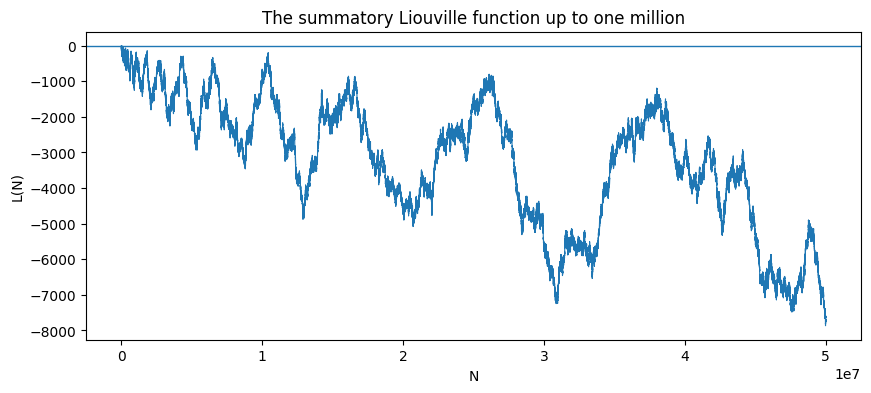

In [13]:

x = np.arange(2, N_TEST + 1)

plt.figure(figsize=(10, 4))
plt.plot(x, L[2:], linewidth=0.8)
plt.axhline(0, linewidth=1)
plt.xlabel("N")
plt.ylabel("L(N)")
plt.title("The summatory Liouville function up to one million")
plt.show()



Our first million experiments do not produce a single positive value of $L(N)$.

It is easy to imagine increasing the computation:

$$
10^6,\quad 10^7,\quad 10^8,\quad \ldots
$$

How long would you continue before becoming convinced?

### The reveal

The conjecture is false.

The **smallest counterexample** occurs at

$$
\boxed{N=906\,150\,257}.
$$

In other words,

$$
L(N)\le 0
$$

for every

$$
2\le N<906\,150\,257,
$$

and then the conjecture finally fails.

A computation checking the first **nine hundred million cases** would therefore have produced nothing but supporting evidence. This is a classic example of a long-lived bias: the signs are not behaving as a naive small sample might suggest, and the exceptional behavior is postponed far beyond the scale of an ordinary experiment.

Pólya's conjecture was disproved theoretically by Haselgrove in 1958. Lehman later found an explicit counterexample, and Tanaka determined the smallest one in 1980. The chronology matters: a proof that a counterexample exists need not immediately tell us where the first counterexample is.

We do not compute all $906$ million values in this notebook: doing so would obscure the conceptual lesson and require a much larger computation than the other examples.

**Source:** [MathWorld: Pólya Conjecture](https://mathworld.wolfram.com/PolyaConjecture.html)


In [14]:

first_polya_counterexample = 906_150_257

print("Our experiment checked:", f"{N_TEST:,}", "values")
print("First counterexample:   ", f"{first_polya_counterexample:,}")
print("Scale factor:           ",
      f"{first_polya_counterexample / N_TEST:.1f} times farther")


Our experiment checked: 50,000,000 values
First counterexample:    906,150,257
Scale factor:            18.1 times farther



## 3. The Mertens conjecture: even $10^{16}$ checks are not enough

The **Möbius function** is defined by

$$
\mu(n)=
\begin{cases}
0,&n\text{ is divisible by the square of a prime},\\
(-1)^k,&n\text{ is a product of }k\text{ distinct primes}.
\end{cases}
$$

The zero values remove integers containing a repeated prime factor, while the values $\pm1$ distinguish square-free integers according to whether they have an even or odd number of prime factors. Its summatory function is

$$
M(N)=\sum_{n\le N}\mu(n).
$$

### The tempting conjecture

Mertens conjectured that

$$
\boxed{|M(N)|<\sqrt N\qquad(N>1).}
$$

Let us look at the normalized quantity

$$
\frac{M(N)}{\sqrt N}.
$$

The conjecture says that this quantity must always remain strictly between $-1$ and $1$. The normalization is crucial: it asks not whether $M(N)$ grows, but whether its fluctuations are always smaller than the square-root scale.


In [15]:

M = np.cumsum(mu.astype(np.int64))

n = np.arange(2, N_TEST + 1)
normalized_M = M[2:] / np.sqrt(n)

print(f"M({N_TEST:,}) =", M[N_TEST])
print("Largest |M(N)|/sqrt(N) in our experiment:",
      np.max(np.abs(normalized_M)))


M(50,000,000) = -908
Largest |M(N)|/sqrt(N) in our experiment: 0.8944271909999159


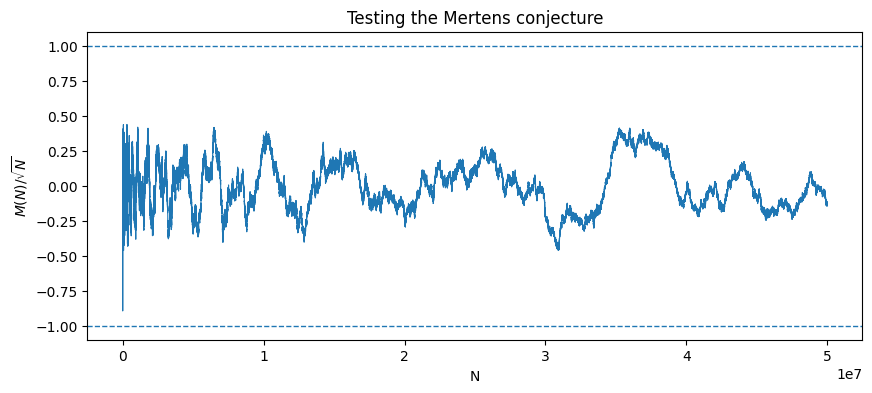

In [16]:

plt.figure(figsize=(10, 4))
plt.plot(n, normalized_M, linewidth=0.8)
plt.axhline(1, linestyle="--", linewidth=1)
plt.axhline(-1, linestyle="--", linewidth=1)
plt.xlabel("N")
plt.ylabel(r"$M(N)/\sqrt{N}$")
plt.title("Testing the Mertens conjecture")
plt.show()



Again, the data look convincing: the plotted curve stays inside the proposed barriers and does not appear close to escaping them. A plot, however, displays a finite window; it cannot show what must happen outside that window.

But this example is even more striking than Pólya's.

### The reveal

Odlyzko and te Riele proved in 1985 that the Mertens conjecture is **false**.

Their proof did **not** produce a specific integer $N$ violating the inequality. Instead, analytic information about the zeros of the Riemann zeta function was combined with lattice-reduction methods to prove that violations must exist. This distinction is important: an **existence proof** can settle a conjecture even when direct search has not located a witness.

Decades later, Greg Hurst reported computation of $M(N)$ for **every**

$$
N\le 10^{16}.
$$

No explicit counterexample was found.

So we have the remarkable situation

$$
\boxed{\text{The conjecture is known to be false, but no explicit counterexample is known.}}
$$

This is an especially important cautionary tale. A universal statement can survive $10^{16}$ direct checks and nevertheless be mathematically false.

**Sources:**

- A. M. Odlyzko and H. J. J. te Riele, *Disproof of the Mertens Conjecture* (1985).
- Greg Hurst, *Computations of the Mertens Function and Improved Bounds on the Mertens Conjecture* (2016):  
  https://arxiv.org/abs/1610.08551



## 4. What should we learn from these examples?

The examples have very different scales.

| Statement | Evidence before failure | Resolution | Main warning |
|:---|---:|:---|:---|
| Fermat numbers are all prime | first 5 cases | $F_5$ is composite | a simple formula need not enforce the observed property |
| Pólya: $L(N)\le0$ | every $N<906\,150\,257$ | explicit counterexample | a numerical bias can persist for a very long time |
| Mertens: $\lvert M(N)\rvert<\sqrt N$ | computed through $10^{16}$ | proved false; no explicit counterexample known | proof and direct search answer different questions |

There are several distinct lessons.

### 1. A universal statement cannot be proved by finite verification

Checking

$$
P(1),P(2),\ldots,P(10^{16})
$$

does not logically imply

$$
P(n)\quad\text{for every }n.
$$

The untested integers are still infinite in number.

### 2. One counterexample is completely different

For a universal statement,

$$
\forall n,\;P(n),
$$

a million positive examples do not constitute a proof.

But one value with

$$
\neg P(n)
$$

is a proof that the statement is false.

This asymmetry is fundamental to experimental mathematics.

### 3. Large-scale evidence is still valuable

The conclusion should **not** be that computation is useless.

Experiments can:

- reveal patterns;
- suggest the correct scale of a phenomenon;
- distinguish plausible conjectures from implausible ones;
- find counterexamples;
- suggest refined conjectures after an initial conjecture fails;
- guide the search for a proof;
- reveal exceptional behavior that theory must explain.

What experiments usually cannot do is turn a finite pattern into an unrestricted universal theorem.

### 4. The right question is not “How many examples did we check?”

The more interesting questions are:

- **Why** should the pattern continue?
- Is there a structural mechanism forcing it?
- Could there be a slowly growing secondary term that eventually dominates?
- Is the observed range representative of the asymptotic regime?
- How should the size of the experiment change our confidence?
- What alternative hypotheses are compatible with the same data?

These are exactly the kinds of questions that make experimental mathematics mathematically interesting.

---

### Final principle

A computation can give overwhelming evidence for a conjecture.

It can also destroy a conjecture with a single example.

But between those two statements lies the central discipline of experimental mathematics:

$$
\boxed{\text{Take the evidence seriously, but do not confuse it with proof.}}
$$



## Further experiments

Try modifying the notebook.

1. Increase `N_TEST` from $10^6$ to $10^7$. How do the graphs of $L(N)$ and $M(N)/\sqrt N$ change?
2. Record the largest and smallest values attained by $L(N)$ and $M(N)/\sqrt N$.
3. Search for long intervals during which one of these quantities appears to have a persistent bias.
4. Invent a conjecture from one of the plots **before** looking farther. Then increase the range and try to break your own conjecture.

The last exercise is perhaps the most characteristic activity in experimental mathematics: use computation not only to accumulate evidence, but also to **attack the patterns that the evidence suggests**.



## References

- E. W. Weisstein, **Pólya Conjecture**, MathWorld:  
  https://mathworld.wolfram.com/PolyaConjecture.html

- G. Hurst, **Computations of the Mertens Function and Improved Bounds on the Mertens Conjecture** (2016):  
  https://arxiv.org/abs/1610.08551

- E. W. Weisstein, **Fermat Number**, MathWorld:  
  https://mathworld.wolfram.com/FermatNumber.html
